# Mini Quant Project: Predictive Trading Strategy on AAPL

This project aims to develop and backtest ML-enhanced trading strategies on Apple stock (AAPL) using historical price data. We explore how incorporating ML classifier, with appropriate parameter optimization, can help improve existing trading strategies.


In [1]:
import os
# print(os.getcwd())
os.chdir('/Users/hkshim/Documents/ml-augmented-momentum-strategy/')
print(os.getcwd())

/Users/hkshim/Documents/ml-augmented-momentum-strategy


## Importing libraries and packages

In [2]:
import yfinance as yf
import pandas as pd
from IPython.display import display, HTML
from src.features import generate_features
from src.model import MLModel
from sklearn.model_selection import train_test_split
from src.strategy import mac_strategy_ml, mac_strategy1
from src.parameter_optimizer import parameter_optimizer1b
from src.utils import plot_strategy, tear_sheet1, plot_cumulative_returns

## Fetching raw data

In [3]:
ticker = 'AAPL'
start_date = '2020-01-01'
end_date = '2025-01-01'

# Download historical stock data
df = yf.download(ticker, start=start_date, end=end_date)
df.columns = df.columns.get_level_values(0)  # Handle multi-index columns if present

print(df.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.620850  72.681296  71.373226  71.627100  135480400
2020-01-03  71.914810  72.676439  71.689950  71.847110  146322800
2020-01-06  72.487839  72.526526  70.783241  71.034702  118387200
2020-01-07  72.146927  72.753808  71.926900  72.497514  108872000
2020-01-08  73.307510  73.609745  71.849533  71.849533  132079200


## Feature generation

In [4]:
# Generate additional features for ML models and strategies
df_add = generate_features(df)

In [5]:
# Display raw and enhanced DataFrames side by side
display(HTML("<h4>Raw Data (df)</h4>"))
display(df.head())

display(HTML("<h4>Feature-Enhanced Data (df_add)</h4>"))
display(df_add.head())

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.620850,72.681296,71.373226,71.627100,135480400
2020-01-03,71.914810,72.676439,71.689950,71.847110,146322800
2020-01-06,72.487839,72.526526,70.783241,71.034702,118387200
2020-01-07,72.146927,72.753808,71.926900,72.497514,108872000
2020-01-08,73.307510,73.609745,71.849533,71.849533,132079200


Price,Close,High,Low,Open,Volume,RSI,MACD,return_1d,return_3d,return_5d,ma5,ma10,mom_10d,vola_5d,vol_mean5,vol_ratio,fwd_return,target
Date,,,,,,,,,,,,,,,,,,
2020-02-07,77.562859,78.379615,77.070866,78.129983,117684000,56.776473,0.953192,-0.013593,0.006083,0.036443,77.128220,76.871934,0.599525,1.503694,130468240.0,0.902013,0.015374,1
2020-02-10,77.931229,77.931229,76.065052,76.145028,109348800,58.030887,0.964512,0.004749,0.002685,0.044233,77.788449,77.195036,3.231018,0.563249,117580320.0,0.929992,-0.007930,0
2020-02-11,77.461075,78.500807,77.242951,78.428101,94323200,55.804848,0.924885,-0.006033,-0.014887,0.004762,77.861879,77.259801,0.647659,0.465524,109121680.0,0.864386,0.012547,1
2020-02-12,79.300591,79.305435,77.911858,77.911858,113730400,61.954191,1.030040,0.023748,0.022404,0.020303,78.177484,77.347729,0.879272,0.777705,108102400.0,1.052062,-0.021088,0
2020-02-13,78.735901,79.063090,78.367514,78.571097,94747600,59.229704,1.055641,-0.007121,0.010325,0.001326,78.198331,77.390550,0.428215,0.794146,105966800.0,0.894125,-0.036384,0


## Model training

In [6]:
# Split the dataset into training and testing sets
# Ensure the split is done without shuffling for time-series data
df_train, df_test = train_test_split(
    df_add,
    test_size=0.3,
    shuffle=False,
    random_state=42
)

print(f"Training samples: {len(df_train)}, Testing samples: {len(df_test)}")

Training samples: 859, Testing samples: 369


In [7]:
# Train the ML model
ml_model = MLModel(model_type="logistic")
ml_model.train(df_train)

## (optional) Strategy Backtesting, no parameter optimization

In [8]:
# ML-enhanced strategy
result_df_ml, final_return_ml = mac_strategy_ml(
    df=df_test,
    sw=10,
    lw=20,
    ml_model=ml_model,
    ml_threshold=0.5
)

# Traditional strategy
result_df_trad, final_return_trad = mac_strategy1(
    df=df_test,
    sw=10,
    lw=20
)


Final cumulative return of the strategy with ML: 44.78%
Final cumulative return of the strategy: 22.29%


## Strategy Backtesting with parameter optimization

In [14]:
# Optimize ML strategy
opt_params_ml, opt_df_ml, param_res_ml = parameter_optimizer1b(
    df_test, mac_strategy_ml, ml_model=ml_model, ml_threshold=0.5
)


# Optimize traditional strategy
opt_params_trad, opt_df_trad, param_res_trad = parameter_optimizer1b(
    df_test, mac_strategy1
)


Max Tuples:[(19, 30, np.float64(0.5204741505206736))]
Optimal Parameters:(19, 30), Optimized Return:52.05%
Final cumulative return of the strategy with ML: 52.05%
Max Tuples:[(21, 35, np.float64(0.36381598982750973))]
Optimal Parameters:(21, 35), Optimized Return:36.38%
Final cumulative return of the strategy: 36.38%


## Performance Comparison

### ML-Enhanced Strategy

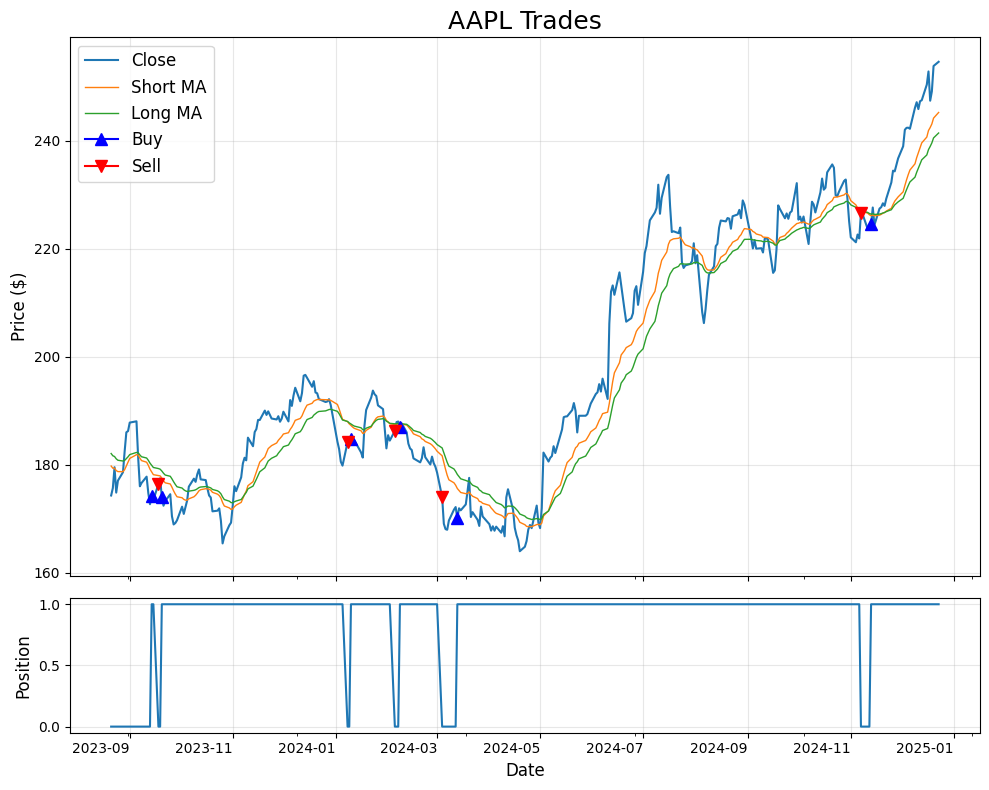

Trading Period: 1.3 years
Final cumulative return of the strategy: 52.05%, Buy & Hold: 46.08%
Strategy CAGR: 36.55%, Benchmark CAGR: 32.54%
Sharpe Ratio: 1.61
Strategy MDD: -15.25%, Benchmark MDD: -16.61%
Number of Profitable Trades: 5, Number of Loss Trades: 1, Win Rate: 83.33%
Average Holding Period: 52.3 days
Avg ROR/trade in profitable trades: 10.920%, Avg ROR/trade in loss trades: -6.901%
Profit/Loss Ratio: 1.58


In [15]:
# Plotting and performance comparison
plot_strategy(opt_df_ml, ticker)
tear_sheet1(opt_df_ml)

### Traditional Strategy

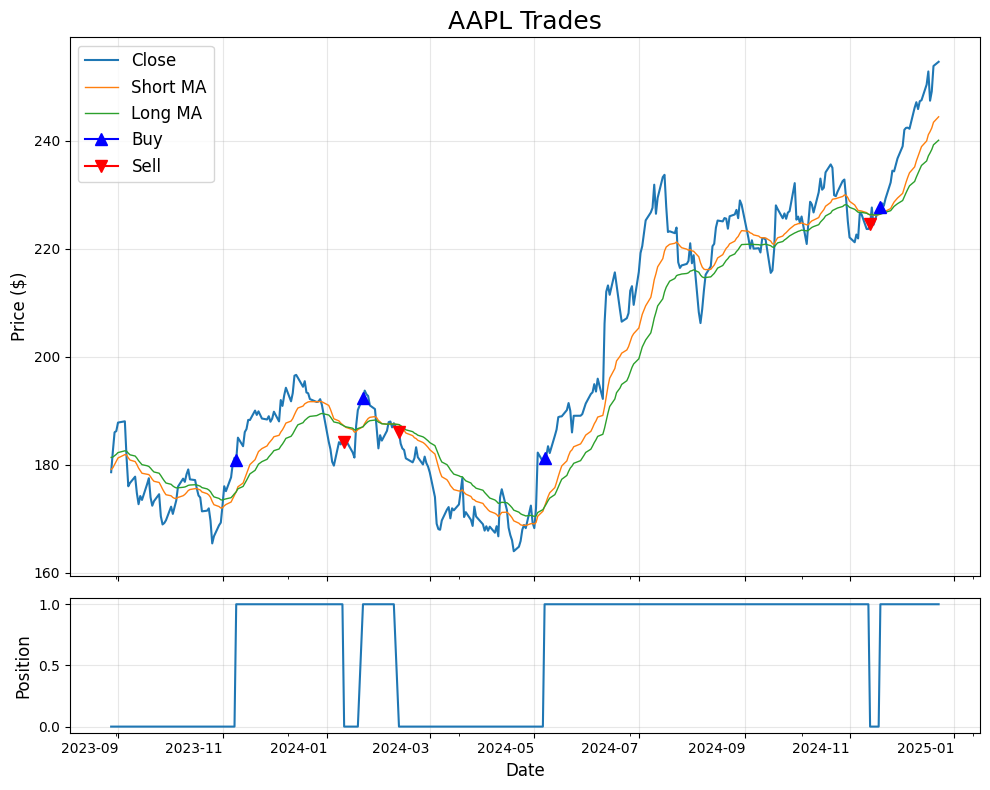

Trading Period: 1.3 years
Final cumulative return of the strategy: 36.38%, Buy & Hold: 42.55%
Strategy CAGR: 26.38%, Benchmark CAGR: 30.67%
Sharpe Ratio: 1.47
Strategy MDD: -11.75%, Benchmark MDD: -16.61%
Number of Profitable Trades: 3, Number of Loss Trades: 1, Win Rate: 75.00%
Average Holding Period: 55.0 days
Avg ROR/trade in profitable trades: 12.523%, Avg ROR/trade in loss trades: -3.353%
Profit/Loss Ratio: 3.73


In [16]:
plot_strategy(opt_df_trad, ticker)
tear_sheet1(opt_df_trad)

### Cumulative return comparison

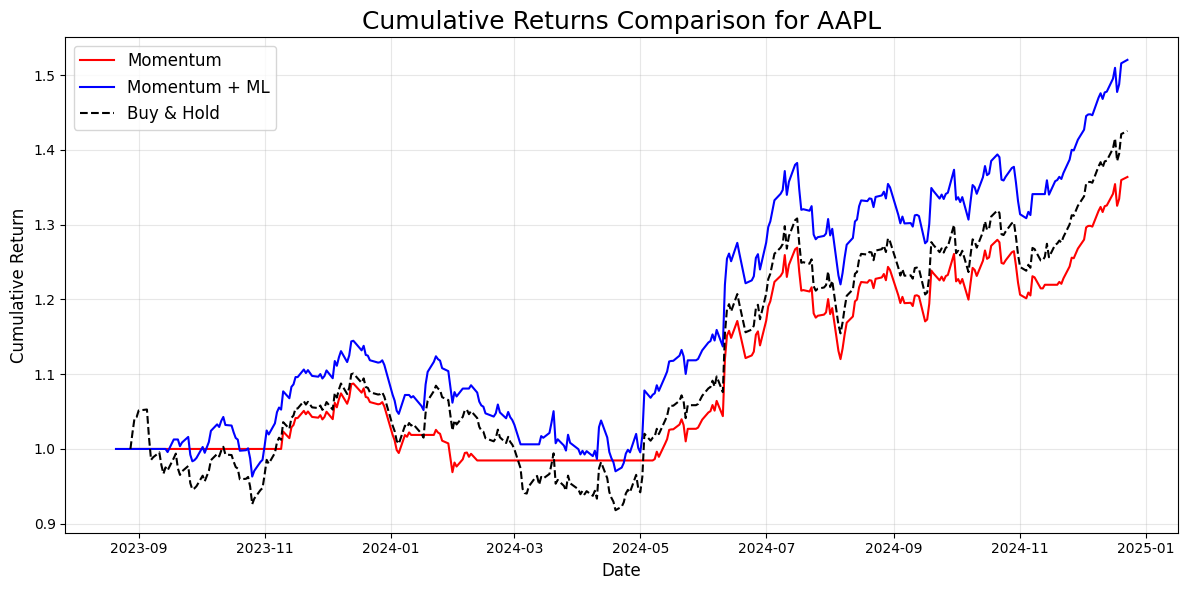

In [17]:
buy_hold_return = df_test['Close'].reindex(opt_df_trad.index) / df_test['Close'].reindex(opt_df_trad.index).iloc[0]

strategies_cum_returns = {
    'Momentum': opt_df_trad['Cumulative_Return'],
    'Momentum + ML': opt_df_ml['Cumulative_Return'],
    'Buy & Hold': buy_hold_return
}

plot_cumulative_returns(strategies_cum_returns, ticker='AAPL')

In [23]:
opt_df_ml['Cumulative_Return'].iloc[-1].item()

1.5204741505206736

## Rolling backtest

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Max Tuples:[(16, 42, np.float64(1.0257730104896274))]
Optimal Parameters:(16, 42), Optimized Return:102.58%
Final cumulative return of the strategy: 102.58%
Final cumulative return of the strategy: 74.50%
Date: 2018-01-01 | Strategy CAGR: 35.57% | MDD: -13.82% | Benchmark CAGR: 33.68% | MDD: -38.52%



[*********************100%***********************]  1 of 1 completed

Max Tuples:[(5, 39, np.float64(0.9056412857999212))]
Optimal Parameters:(5, 39), Optimized Return:90.56%
Final cumulative return of the strategy: 90.56%
Final cumulative return of the strategy: 95.76%
Date: 2018-07-01 | Strategy CAGR: 44.02% | MDD: -17.69% | Benchmark CAGR: 33.83% | MDD: -38.52%



[*********************100%***********************]  1 of 1 completed

...


[*********************100%***********************]  1 of 1 completed

Max Tuples:[(5, 25, np.float64(4.475378931785288))]
Optimal Parameters:(5, 25), Optimized Return:447.54%
Final cumulative return of the strategy: 447.54%
Final cumulative return of the strategy: 37.10%
Date: 2021-07-01 | Strategy CAGR: 18.10% | MDD: -23.86% | Benchmark CAGR: 16.60% | MDD: -30.91%



[*********************100%***********************]  1 of 1 completed

Max Tuples:[(5, 23, np.float64(4.685302838963337))]
Optimal Parameters:(5, 23), Optimized Return:468.53%
Final cumulative return of the strategy: 468.53%
Final cumulative return of the strategy: 21.07%
Date: 2022-01-01 | Strategy CAGR: 10.61% | MDD: -22.81% | Benchmark CAGR: 6.45% | MDD: -29.82%


Max Tuples:[(5, 23, np.float64(3.818545535924863))]
Optimal Parameters:(5, 23), Optimized Return:381.85%
Final cumulative return of the strategy: 381.85%
Final cumulative return of the strategy: 17.06%
Date: 2022-07-01 | Strategy CAGR: 8.66% | MDD: -19.21% | Benchmark CAGR: 14.00% | MDD: -28.26%


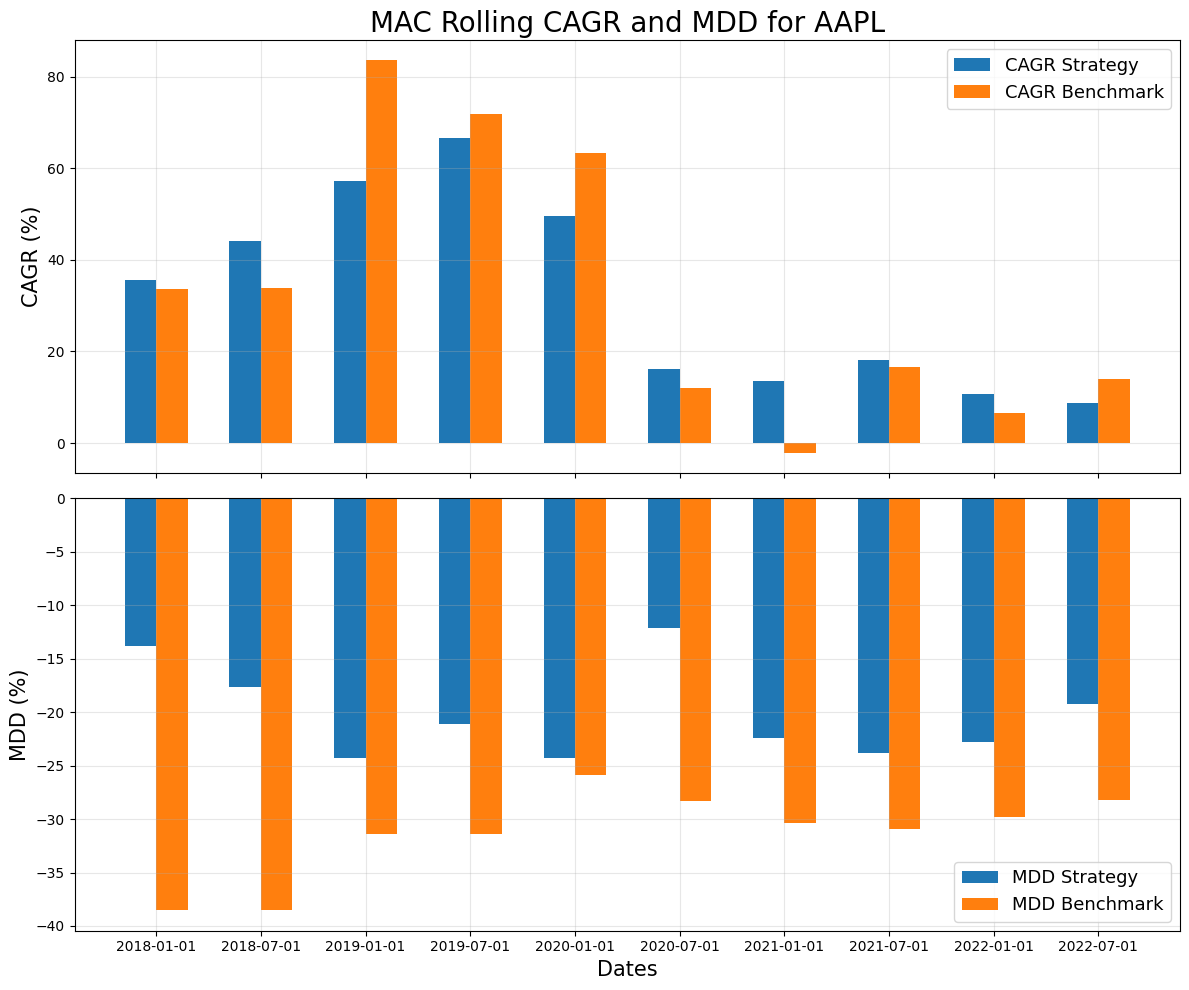

In [18]:
# Rolling backtest for both strategies
from src.utils import rolling_test
from src.utils import plot_rolling_performance

# Choose strategy and optimizer
strat = mac_strategy1 # mac_strategy_ml  # or mac_strategy1
opt = parameter_optimizer1b
ticker = 'AAPL'

# Rolling test dates
dates = [
    '2018-01-01', '2018-07-01', '2019-01-01', '2019-07-01', '2020-01-01',
    '2020-07-01', '2021-01-01', '2021-07-01', '2022-01-01', '2022-07-01'
]

# Initialize result container
metrics = ['CAGR', 'MDD']
results = {('Strategy', m): [] for m in metrics}
results.update({('Benchmark', m): [] for m in metrics})

# Run rolling backtest
for date in dates:
    kwargs = {}
    if strat == mac_strategy_ml:
        kwargs = {'ml_model': ml_model, 'ml_threshold': 0.7}
    
    cagr_s, mdd_s, cagr_b, mdd_b = rolling_test(ticker, date, strat, opt, **kwargs)
    
    results[('Strategy', 'CAGR')].append(cagr_s)
    results[('Strategy', 'MDD')].append(mdd_s)
    results[('Benchmark', 'CAGR')].append(cagr_b)
    results[('Benchmark', 'MDD')].append(mdd_b)

    print(
        f"Date: {date} | "
        f"Strategy CAGR: {100 * cagr_s:.2f}% | MDD: {100 * mdd_s:.2f}% | "
        f"Benchmark CAGR: {100 * cagr_b:.2f}% | MDD: {100 * mdd_b:.2f}%"
    )

# Create DataFrame
results_df = pd.DataFrame(results, index=dates)
results_df

# plotting the rolling performance
plot_rolling_performance(results_df, dates, ticker)